---

#**LIBRARIES INSTALLATION**

---


In [1]:
!pip install contractions
!pip install spacy
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


This cell installs the necessary Python libraries used for text preprocessing. Each of these packages plays a different role in cleaning and analyzing textual data.

The contractions package allows us to expand shortened words like “don’t” into “do not,” which improves consistency and accuracy during later stages like tokenization and lemmatization. Spacy is a powerful NLP library that provides tools for tokenization, part-of-speech tagging, and lemmatization. The last line downloads the small English language model en_core_web_sm for SpaCy, which contains the vocabulary and rules needed for processing English text.

This setup cell ensures that all the tools we need are installed before we begin preprocessing the tweets.

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import html
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import contractions
from nltk.tokenize import TweetTokenizer
import spacy
from nltk.corpus import wordnet
from nltk import pos_tag
import matplotlib.pyplot as plt


nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

This cell imports all the Python libraries and modules needed for the preprocessing workflow. It includes tools for data handling, regular expressions, tokenization, lemmatization, part-of-speech tagging, and more.

The code begins by importing common libraries like pandas and numpy, which are used for working with structured data. The re and html modules help in cleaning tweets by handling regular expressions and decoding HTML entities.

Several Natural Language Toolkit (NLTK) components are also imported, such as tokenizers, stopwords, and the WordNet lemmatizer. These are essential for breaking tweets into words and converting them to their root forms. The contractions package help normalize informal or mashed-up language. TweetTokenizer is a tokenizer specifically designed to handle social media text more accurately.

The spacy and pos_tag tools are used to help with identifying the grammatical roles of words, which improves the quality of lemmatization later on.

Finally, the nltk.download() commands ensure that all required datasets are available locally. These include stopword lists, wordnet dictionaries, and pre-trained models for tokenization and part-of-speech tagging. Without these downloads, the functions we use later would not work properly.

---

#**IMPORT AND LOAD OF DATASET**

---


In [3]:
df = pd.read_csv('labeled_data.csv')

pd.set_option('display.max_colwidth', None)

df.head(10)

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;
5,5,3,1,2,0,1,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just blows me..claim you so faithful and down for somebody but still fucking with hoes! &#128514;&#128514;&#128514;"""
6,6,3,0,3,0,1,"!!!!!!""@__BrighterDays: I can not just sit up and HATE on another bitch .. I got too much shit going on!"""
7,7,3,0,3,0,1,!!!!&#8220;@selfiequeenbri: cause I'm tired of you big bitches coming for us skinny girls!!&#8221;
8,8,3,0,3,0,1,""" &amp; you might not get ya bitch back &amp; thats that """
9,9,3,1,2,0,1,""" @rhythmixx_ :hobbies include: fighting Mariam""\n\nbitch"


This cell loads the dataset and displays its first few entries. The read_csv() function is used to import the labeled_data.csv file, which contains tweets labeled for hate speech and offensive language. The dataset includes metadata like the number of annotators and their judgments, along with the tweet text itself.

The pd.set_option('display.max_colwidth', None) line ensures that long tweets are shown in full when displaying the DataFrame, instead of being truncated. Finally, df.head(10) prints the first ten rows so we can inspect the raw structure and content of the data before cleaning begins. This step is useful for understanding what kind of preprocessing is needed.

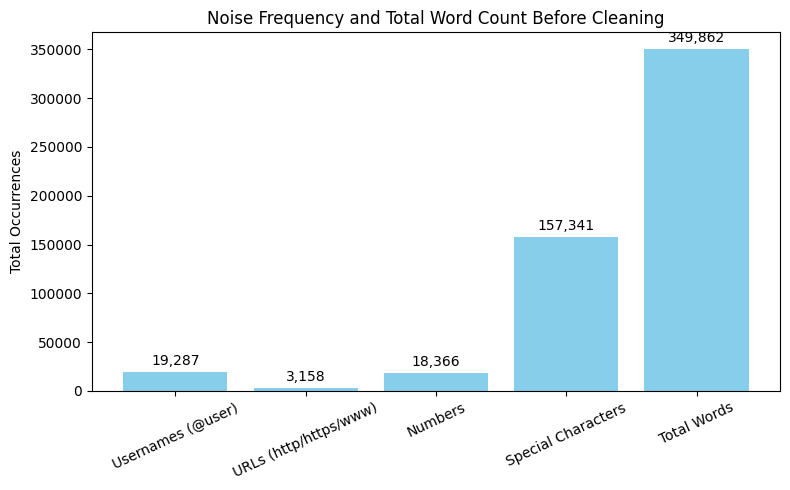

In [4]:
patterns = {
    'Usernames (@user)': r'@\w+',
    'URLs (http/https/www)': r'http\S+|www\S+|https\S+',
    'Numbers': r'\b\d+\b',
    'Special Characters': r'[^A-Za-z0-9\s]'
}

noise_counts_before = {label: df['tweet'].str.count(pattern).sum() for label, pattern in patterns.items()}

total_words_before = df['tweet'].str.split().apply(len).sum()
noise_counts_before['Total Words'] = total_words_before

plt.figure(figsize=(8,5))
bars = plt.bar(noise_counts_before.keys(), noise_counts_before.values(), color='skyblue')
plt.title('Noise Frequency and Total Word Count Before Cleaning')
plt.ylabel('Total Occurrences')
plt.xticks(rotation=25)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


This code counts the occurrences of common noise types in the tweet texts by searching for specific patterns using regular expressions. The noise types checked include usernames (words starting with @), URLs (starting with http, https, or www), numbers, and special characters (anything that is not a letter, number, or whitespace). For each noise type, the code sums the total matches found across all tweets.

The resulting counts are then visualized in a bar chart to give a clear overview of how much noise exists in the dataset. When run on the original raw tweets, this shows the initial noise level before cleaning.

---

#**LOWERCASING THE DATASET**

---

In [5]:
testcase_text = df.loc[3, 'tweet']
print(testcase_text)

!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny


One tweet was picked from the dataset using its row index to serve as a sample for testing the preprocessing steps. This tweet includes typical social media elements like multiple exclamation points, user mentions, informal language, and possibly offensive content. It will be used to demonstrate how each preprocessing function transforms raw text into a cleaner and more structured format.

In [6]:
lowercased_test = testcase_text.lower()
print( lowercased_test)

!!!!!!!!! rt @c_g_anderson: @viva_based she look like a tranny


The selected tweet was converted to lowercase using the `.lower()` function. This step ensures uniformity by eliminating case sensitivity. Lowercasing is a common preprocessing task in NLP, as it helps treat words like "She" and "she" as the same during analysis. The text structure remains unchanged except for all characters being in lowercase.


In [7]:
df['tweet'] = df['tweet'].apply(lambda x: str(x).lower())

df[['tweet']].head(10)

,tweet
0,!!! rt @mayasolovely: as a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
1,!!!!! rt @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2,!!!!!!! rt @urkindofbrand dawg!!!! rt @80sbaby4life: you ever fuck a bitch and she start to cry? you be confused as shit
3,!!!!!!!!! rt @c_g_anderson: @viva_based she look like a tranny
4,!!!!!!!!!!!!! rt @shenikaroberts: the shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;
5,"!!!!!!!!!!!!!!!!!!""@t_madison_x: the shit just blows me..claim you so faithful and down for somebody but still fucking with hoes! &#128514;&#128514;&#128514;"""
6,"!!!!!!""@__brighterdays: i can not just sit up and hate on another bitch .. i got too much shit going on!"""
7,!!!!&#8220;@selfiequeenbri: cause i'm tired of you big bitches coming for us skinny girls!!&#8221;
8,""" &amp; you might not get ya bitch back &amp; thats that """
9,""" @rhythmixx_ :hobbies include: fighting mariam""\n\nbitch"


All tweets in the dataset were converted to lowercase using the `.apply()` function with a lambda expression. This ensures that every entry in the 'tweet' column is treated as a lowercase string. Lowercasing helps remove inconsistencies caused by different capitalizations of the same word, which is important for accurate tokenization, comparison, and analysis. A preview of the first 10 lowercase tweets confirms the change.

---
#**CONTRACTIONS EXPANSION**
---

In [8]:
def expand_contractions(text):
    return contractions.fix(text)

df['tweet'] = df['tweet'].apply(expand_contractions)

pd.set_option('display.max_colwidth', None)

df[['tweet']].head(10)

,tweet
0,!!! rt @mayasolovely: as a woman you should not complain about cleaning up your house. &amp; as a man you should always take the trash out...
1,!!!!! rt @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2,!!!!!!! rt @urkindofbrand dawg!!!! rt @80sbaby4life: you ever fuck a bitch and she start to cry? you be confused as shit
3,!!!!!!!!! rt @c_g_anderson: @viva_based she look like a tranny
4,!!!!!!!!!!!!! rt @shenikaroberts: the shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;
5,"!!!!!!!!!!!!!!!!!!""@t_madison_x: the shit just blows me..claim you so faithful and down for somebody but still fucking with hoes! &#128514;&#128514;&#128514;"""
6,"!!!!!!""@__brighterdays: i can not just sit up and hate on another bitch .. i got too much shit going on!"""
7,!!!!&#8220;@selfiequeenbri: because i am tired of you big bitches coming for us skinny girls!!&#8221;
8,""" &amp; you might not get ya bitch back &amp; that is that """
9,""" @rhythmixx_ :hobbies include: fighting mariam""\n\nbitch"


Contractions in the tweets were expanded using the `contractions` library. A function was used to apply `contractions.fix()` to each tweet, replacing shortened forms such as you're or it's with their full versions like you are or it is. This helps make the text clearer and easier to process in later steps such as tokenization or classification. The output confirms that contractions were successfully expanded, improving consistency in the dataset.

---
#**SPECIAL CHARACTERS REMOVAL**
---

## **Regular Expression (RegEx) Removal**

In [9]:
test_case = df['tweet'][0]
print("Before cleaning:", test_case)

Before cleaning: !!! rt @mayasolovely: as a woman you should not complain about cleaning up your house. &amp; as a man you should always take the trash out...


A sample tweet from the dataset was displayed to show its current state after lowercase conversion and contraction expansion. This tweet still contains unnecessary characters and HTML encodings like `&amp;`, which will be removed in the following cleaning steps to prepare the text for analysis.

In [10]:
test_case = re.sub("[^a-zA-Z0-9\s]", '', test_case)
print("After Regex Cleaning:", test_case)

After Regex Cleaning:  rt mayasolovely as a woman you should not complain about cleaning up your house amp as a man you should always take the trash out


This step applies a regular expression to remove all characters from the tweet that are not letters, digits, or whitespace. Specifically, it removes punctuation and special characters like exclamation marks (`!`), colons (`:`), and HTML encodings (`&amp;` becomes `amp`). The result is a cleaner, more uniform version of the tweet, which is easier to tokenize and analyze in downstream tasks like hate speech detection.


In [11]:
df['tweet'] = df['tweet'].apply(lambda x: re.sub("[^a-zA-Z0-9\s]", '', str(x)))

A regular expression was used to remove all characters from the tweet that are not letters, numbers, or whitespace. This helps eliminate punctuation and special symbols that are unnecessary for analysis.



In [12]:
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'\d+', '', x))

Another regular expression was applied to remove all numeric digits from the tweets. This is done to ensure that only meaningful text remains for processing.

In [13]:
print(df['tweet'][0])

 rt mayasolovely as a woman you should not complain about cleaning up your house amp as a man you should always take the trash out


A cleaned tweet was printed from the dataset to check the results. The output shows that the tweet now contains only lowercase letters and spaces, confirming that unwanted characters and numbers were removed successfully.

## **@Username Mentions Anonymization**

In [14]:
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'@\w+', '<USER>', x))

All usernames starting with @ are replaced with the placeholder <USER> to anonymize the data and remove personal mentions that do not contribute to sentiment or hate speech analysis.

## **URLs Removal**

In [15]:
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x))

All URLs beginning with http, https, or www are removed from the tweets to clean up links that may distract from the main textual content.

## **Numbers Removal (Except whitelisted numbers)**

In [16]:
whitelist_numbers = {'911', '100', '420', '666', '69'}  # Add more as needed

def remove_non_whitelisted_numbers(text):
    return re.sub(r'\b\d+\b', lambda m: m.group() if m.group() in whitelist_numbers else '', text)

df['tweet'] = df['tweet'].apply(remove_non_whitelisted_numbers)


This step removes all standalone numbers from the tweets except those in the defined whitelist (such as 911, 420, 666). These whitelisted numbers are preserved due to their potential cultural or contextual relevance in text analysis.

## **HTML Entities Removal**

In [17]:
df['tweet'] = df['tweet'].apply(lambda x: html.unescape(x))

df['tweet'] = df['tweet'].str.replace(r'^rt\s+', '', regex=True)

This step performs two cleaning actions in a single cell. First, it converts any HTML entities in the tweets—such as `&amp;`—into their readable character equivalents, like `&`, using the `html.unescape()` function. This makes the text easier to understand and process. Second, it removes the "rt" marker at the beginning of tweets, which stands for "retweet." This is done using a regular expression that targets only "rt" at the start of the string, helping to simplify the tweet content and reduce noise in the data.

## **Non-aplhanumeric Characters Removal**

In [18]:
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s.,!?\'\"]', '', x))

This line removes all characters from each tweet that are not letters, numbers, spaces, or basic punctuation marks like periods, commas, exclamation points, question marks, single quotes, and double quotes. By keeping only these selected characters, the tweet text becomes cleaner and more consistent while still preserving useful punctuation that may carry meaning or tone.

## **Extra Spaces Removal**

In [19]:
df['tweet'] = df['tweet'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

This cell removes extra spaces in the tweet text by replacing multiple whitespace characters with a single space and trimming any leading or trailing spaces. This results in a more uniform text structure.

## **Post-Special Characters Removal Output**

In [20]:
pd.set_option('display.max_colwidth', None)
df[['tweet']].head(10)

,tweet
0,rt mayasolovely as a woman you should not complain about cleaning up your house amp as a man you should always take the trash out
1,rt mleew boy dats coldtyga dwn bad for cuffin dat hoe in the st place
2,rt urkindofbrand dawg rt sbabylife you ever fuck a bitch and she start to cry you be confused as shit
3,rt cganderson vivabased she look like a tranny
4,rt shenikaroberts the shit you hear about me might be true or it might be faker than the bitch who told it to ya
5,tmadisonx the shit just blows meclaim you so faithful and down for somebody but still fucking with hoes
6,brighterdays i can not just sit up and hate on another bitch i got too much shit going on
7,selfiequeenbri because i am tired of you big bitches coming for us skinny girls
8,amp you might not get ya bitch back amp that is that
9,rhythmixx hobbies include fighting mariam bitch


This cell adjusts the display setting so full tweet texts are shown without being cut off, then displays the first 10 cleaned tweets to visually confirm the preprocessing results. The following processes were applied beforehand:

* Regex-based character cleaning
* Removal of @username mentions
* Removal of URLs (like http, https, www links)
* Removal of numbers (except for whitelisted ones like 911, 420, etc.)
* Conversion of HTML entities to readable text (such as &amp; to &)
* Removal of non-alphanumeric characters (except for selected punctuation)
* Removal of extra whitespace

---
#**STOP WORDS REMOVAL**
---

In [21]:
stop_words = stopwords.words('english')
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

This cell loads the standard list of English stopwords from the NLTK library. Stopwords are common words such as the, is, in, and, of that are often removed in natural language processing tasks because they carry little meaningful content. The list includes contractions and variations like don't, you're, and couldn't, which helps filter out grammatical noise before further text analysis.

In [22]:
test_case = df['tweet'][0]
print(test_case)

final_test = []
for word in test_case.split():
    if word == '' or '\r\n' in word or word in stop_words:
        None
    else:
        final_test.append(word)

print(final_test)
print(' '.join(final_test))

rt mayasolovely as a woman you should not complain about cleaning up your house amp as a man you should always take the trash out
['rt', 'mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'amp', 'man', 'always', 'take', 'trash']
rt mayasolovely woman complain cleaning house amp man always take trash


This cell demonstrates how to manually filter out stopwords from a tweet. A sample tweet is selected from the dataset and tokenized by splitting it into individual words. Each word is checked: if it is a stopword, an empty string, or contains newline characters, it is skipped. Otherwise, the word is added to a new list. The result is a cleaned version of the tweet that retains only the meaningful content, ready for further analysis.

In [23]:
def remove_stopwords(article, stopwords):
    temp_fnl = []
    for word in article.split():
        if word == '' or '\r\n' in word or word in stopwords:
            None
        else:
            temp_fnl.append(word)
    return ' '.join(temp_fnl)


remove_stopwords(test_case, stop_words)

'rt mayasolovely woman complain cleaning house amp man always take trash'

This cell defines a function remove_stopwords() that filters out common stopwords from a given string. The function splits the input text into individual words, checks each one against a provided stopword list, and excludes any matches, as well as empty or newline-containing strings. The remaining words are joined back into a cleaned sentence. The function is then tested on a sample tweet, successfully removing the stopwords and keeping only the informative terms.

In [24]:
df['tweet'] = df['tweet'].apply(lambda x: remove_stopwords(x, stop_words))

pd.set_option('display.max_colwidth', None)
df[['tweet']].head(10)

,tweet
0,rt mayasolovely woman complain cleaning house amp man always take trash
1,rt mleew boy dats coldtyga dwn bad cuffin dat hoe st place
2,rt urkindofbrand dawg rt sbabylife ever fuck bitch start cry confused shit
3,rt cganderson vivabased look like tranny
4,rt shenikaroberts shit hear might true might faker bitch told ya
5,tmadisonx shit blows meclaim faithful somebody still fucking hoes
6,brighterdays sit hate another bitch got much shit going
7,selfiequeenbri tired big bitches coming us skinny girls
8,amp might get ya bitch back amp
9,rhythmixx hobbies include fighting mariam bitch


This cell applies the previously defined remove_stopwords() function to every tweet in the dataset, effectively removing common, uninformative words from each one. This enhances the clarity and focus of the text data by keeping only meaningful content. After applying the function, the updated DataFrame is previewed using head(10) with the column width setting adjusted to display each tweet in full after the recent preprocessing steps.

---
#**TOKENIZATION**
---

In [25]:
from nltk.tokenize import word_tokenize

test_case = df['tweet'][0]
print("Original:", test_case)

tokens = word_tokenize(test_case)
print("Tokens:", tokens)

Original: rt mayasolovely woman complain cleaning house amp man always take trash
Tokens: ['rt', 'mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'amp', 'man', 'always', 'take', 'trash']



This cell demonstrates the use of NLTK's word_tokenize function by selecting a sample tweet and breaking it down into individual word tokens. Tokenization is a crucial preprocessing step in NLP that splits raw text into smaller units called tokens, which helps in further analysis such as classification or frequency analysis. The original tweet and its resulting token list are printed to show how the text is segmented.

In [26]:
from nltk.tokenize import TweetTokenizer

tweet_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=False, reduce_len=True)

df['tokenized'] = df['tweet'].apply(lambda x: tweet_tokenizer.tokenize(x))

This cell uses NLTK's TweetTokenizer, a tokenizer designed specifically for tweets, to handle features like hashtags, mentions, repeated characters, and emoticons more effectively. It is initialized with settings to convert text to lowercase (preserve_case=False), keep Twitter handles (strip_handles=False), and reduce repeated character sequences (reduce_len=True). The tokenizer is then applied to every tweet in the dataset, and the resulting list of tokens is stored in a new column called tokenized.

In [27]:
stop_words = set(stopwords.words('english')) - {'not', 'no'}

def clean_tokens(tokens):
    return [t for t in tokens if (t.isalpha() or t in ['<USER>', '<URL>']) and len(t) > 1
            and t not in stop_words and t != 'rt' and t != 'amp'
]

df['tokenized'] = df['tokenized'].apply(clean_tokens)

This cell refines the tokenized tweets by filtering out unnecessary or uninformative words. First, it defines a customized list of English stopwords with 'not' and 'no' purposely retained due to their importance in sentiment context. Then, it defines a function clean_tokens() that removes tokens which are not alphabetic, unless they are USER or URL, are shorter than two characters, are stopwords, or are common non-content tokens like 'rt' (retweet) and 'amp' (HTML for '&'). This function is applied to each tweet's token list, overwriting the original tokenized column with cleaned versions.

In [28]:
test_tweet = df['tweet'][0]

print("Original Tweet:")
print(test_tweet)
print("\nword_tokenize:")
print(word_tokenize(test_tweet))
print("\nCleaned Tokens (TweetTokenizer):")
print(clean_tokens(tweet_tokenizer.tokenize(test_tweet)))

Original Tweet:
rt mayasolovely woman complain cleaning house amp man always take trash

word_tokenize:
['rt', 'mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'amp', 'man', 'always', 'take', 'trash']

Cleaned Tokens (TweetTokenizer):
['mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'man', 'always', 'take', 'trash']


This test cell highlights the difference between word_tokenize and the customized TweetTokenizer combined with the clean_tokens() function. The default word_tokenize splits the tweet into all tokens, including uninformative ones like 'rt', 'amp', and common stopwords, which add noise to the analysis.

 In contrast, the TweetTokenizer—specifically designed for social media text—handles informal language more effectively, and when paired with the clean_tokens() filter, removes unwanted tokens and keeps only meaningful words.

Based on this observation, the TweetTokenizer approach is clearly more effective for preprocessing tweets, as it produces cleaner, more relevant tokens for downstream tasks like classification or analysis.

---
#**LEMMATIZATION**
---

In [29]:
from nltk import pos_tag, WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

critical_pronouns = {'us', 'we', 'you', 'i', 'they'}

def get_wordnet_pos(treebank_tag, word=''):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        if word.endswith('ing') or word.endswith('ed'):
            return wordnet.VERB
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def lemmatize_tokens(tokens):
    tagged_tokens = pos_tag(tokens)
    return [
        word if word in critical_pronouns
        else lemmatizer.lemmatize(word, get_wordnet_pos(pos, word))
        for word, pos in tagged_tokens
    ]

def normalize_informal_words(tokens):
    replacements = {
        'u': 'you',
        'ur': 'your',
        'ya': 'you',
        'r': 'are',
        "ya'll": 'you all',
        'dats': 'that',
        'dat': 'that',
        'dwn': 'down'
    }
    return [replacements.get(word, word) for word in tokens]


This cell enhances the preprocessing stage by introducing informal word normalization and lemmatization. The normalize_informal_words() function replaces casual or abbreviated terms commonly found in tweets, such as "u" being changed to "you", "dat" to "that", and "dwn" to "down". This helps standardize the language before more complex processing steps. After normalization, the lemmatize_tokens() function reduces each word to its base form, or lemma, using part-of-speech tagging to ensure accuracy. For instance, a verb like "running" would be reduced to "run" if correctly tagged. A helper function, get_wordnet_pos(), maps each POS tag to a format compatible with the WordNet lemmatizer. Pronouns like "we", "us", and "you" are preserved in their original form to maintain clarity and context. Together, these steps refine the tokens to be more uniform and semantically clear, which is essential for further NLP tasks.

In [30]:
df['lemmatized'] = df['tokenized'].apply(lemmatize_tokens)

df['normalized'] = df['tokenized'].apply(normalize_informal_words)

df['lemmatized'] = df['normalized'].apply(lemmatize_tokens)

This cell applies both informal word normalization and lemmatization to the tokenized tweets. First, df['normalized'] = df['tokenized'].apply(normalize_informal_words) processes each token list to replace informal words like "u" with "you", or "dat" with "that", ensuring more standard vocabulary. Then, df['lemmatized'] = df['normalized'].apply(lemmatize_tokens) reduces each normalized word to its base form using part-of-speech tagging, such as turning "running" into "run" or "houses" into "house". This two-step process ensures that tweets are cleaned of slang and structurally simplified for consistent analysis.

In [31]:
test_index = 0
print("Original:", df['tweet'][test_index])
print("Tokenized:", df['tokenized'][test_index])
print("Normalized:", df['normalized'][test_index])
print("Lemmatized:", df['lemmatized'][test_index])

Original: rt mayasolovely woman complain cleaning house amp man always take trash
Tokenized: ['mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'man', 'always', 'take', 'trash']
Normalized: ['mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'man', 'always', 'take', 'trash']
Lemmatized: ['mayasolovely', 'woman', 'complain', 'clean', 'house', 'man', 'always', 'take', 'trash']


This output illustrates how the tweet is transformed through each preprocessing stage. The original tweet contains informal structure and lacks punctuation. After tokenization, it’s split into individual words. The normalization stage doesn’t change any words here because none match the defined slang terms. In the lemmatization step, "cleaning" becomes "clean", showing how words are reduced to their base form for consistency. This step-by-step transformation helps make the data more uniform and useful for analysis, and possible ready for future use to NLP models.

---
#**POST-PREPROCESSING OUTPUT**
---

In [32]:
original_tweets = pd.read_csv('labeled_data.csv')['tweet']

df['raw_tweet'] = original_tweets

Loads the original, unprocessed tweets from the labeled_data.csv file and stores them in a new column called raw_tweet in the existing DataFrame df. This is done for visualization and comparison purposes, allowing us to view the original text side-by-side with the cleaned version after preprocessing.

In [33]:
pd.set_option('display.max_colwidth', None)

df[['raw_tweet', 'tweet', 'tokenized', 'lemmatized', 'class']].head(10)

,raw_tweet,tweet,tokenized,lemmatized,class
0,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,rt mayasolovely woman complain cleaning house amp man always take trash,"[mayasolovely, woman, complain, cleaning, house, man, always, take, trash]","[mayasolovely, woman, complain, clean, house, man, always, take, trash]",2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,rt mleew boy dats coldtyga dwn bad cuffin dat hoe st place,"[mleew, boy, dats, coldtyga, dwn, bad, cuffin, dat, hoe, st, place]","[mleew, boy, that, coldtyga, down, bad, cuffin, that, hoe, st, place]",1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,rt urkindofbrand dawg rt sbabylife ever fuck bitch start cry confused shit,"[urkindofbrand, dawg, sbabylife, ever, fuck, bitch, start, cry, confused, shit]","[urkindofbrand, dawg, sbabylife, ever, fuck, bitch, start, cry, confuse, shit]",1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,rt cganderson vivabased look like tranny,"[cganderson, vivabased, look, like, tranny]","[cganderson, vivabased, look, like, tranny]",1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,rt shenikaroberts shit hear might true might faker bitch told ya,"[shenikaroberts, shit, hear, might, true, might, faker, bitch, told, ya]","[shenikaroberts, shit, hear, might, true, might, faker, bitch, told, you]",1
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just blows me..claim you so faithful and down for somebody but still fucking with hoes! &#128514;&#128514;&#128514;""",tmadisonx shit blows meclaim faithful somebody still fucking hoes,"[tmadisonx, shit, blows, meclaim, faithful, somebody, still, fucking, hoes]","[tmadisonx, shit, blow, meclaim, faithful, somebody, still, fuck, hoe]",1
6,"!!!!!!""@__BrighterDays: I can not just sit up and HATE on another bitch .. I got too much shit going on!""",brighterdays sit hate another bitch got much shit going,"[brighterdays, sit, hate, another, bitch, got, much, shit, going]","[brighterdays, sit, hate, another, bitch, get, much, shit, go]",1
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of you big bitches coming for us skinny girls!!&#8221;,selfiequeenbri tired big bitches coming us skinny girls,"[selfiequeenbri, tired, big, bitches, coming, us, skinny, girls]","[selfiequeenbri, tire, big, bitch, come, us, skinny, girl]",1
8,""" &amp; you might not get ya bitch back &amp; thats that """,amp might get ya bitch back amp,"[might, get, ya, bitch, back]","[might, get, you, bitch, back]",1
9,""" @rhythmixx_ :hobbies include: fighting Mariam""\n\nbitch",rhythmixx hobbies include fighting mariam bitch,"[rhythmixx, hobbies, include, fighting, mariam, bitch]","[rhythmixx, hobby, include, fight, mariam, bitch]",1


df[['raw_tweet', 'tweet', 'tokenized', 'lemmatized', 'class']].head(10) selects and displays the first ten rows of five key columns:

* **raw_tweet** shows the original, unprocessed tweet as it appears in the source dataset.

* **tweet** contains the cleaned version of the tweet, with noise such as URLs, special characters, and excessive whitespace removed.

* **tokenized** breaks the cleaned tweet into individual words or tokens.

* **lemmatized** further processes each token by reducing it to its root or base form (e.g., "blows" becomes "blow", "girls" becomes "girl").

* **class** indicates the tweet's classification label: 0 for hate speech, 1 for offensive language, and 2 for neither (neutral content).

This output is useful for visually confirming that each step of the preprocessing pipeline—cleaning, tokenization, and lemmatization—is functioning correctly, and for checking whether the classification labels correspond appropriately to the content.

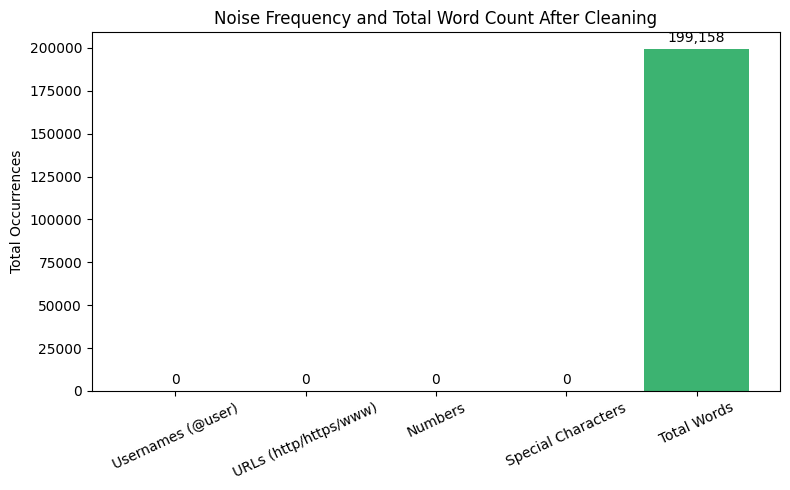

In [34]:
patterns = {
    'Usernames (@user)': r'@\w+',
    'URLs (http/https/www)': r'http\S+|www\S+|https\S+',
    'Numbers': r'\b\d+\b',
    'Special Characters': r'[^A-Za-z0-9\s]'
}

noise_counts_after = {label: df['tweet'].str.count(pattern).sum() for label, pattern in patterns.items()}

df['word_count_after'] = df['tweet'].apply(lambda x: len(x.split()))
total_words_after = df['word_count_after'].sum()
noise_counts_after['Total Words'] = total_words_after

plt.figure(figsize=(8,5))
bars = plt.bar(noise_counts_after.keys(), noise_counts_after.values(), color='mediumseagreen')
plt.ylabel('Total Occurrences')
plt.title('Noise Frequency and Total Word Count After Cleaning')
plt.xticks(rotation=25)

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


This code counts the occurrences of common noise types in the tweet texts by searching for specific patterns using regular expressions. The noise types checked include usernames (words starting with @), URLs (starting with http, https, or www), numbers, and special characters (anything that is not a letter, number, or whitespace). For each noise type, the code sums the total matches found across all tweets.

The resulting counts are then visualized in a bar chart to give a clear overview of how much noise exists in the dataset. When run on the original raw tweets, this shows the initial noise level before cleaning. When run on the cleaned tweets, it reveals how much noise remains after preprocessing, helping to assess the cleaning effectiveness.

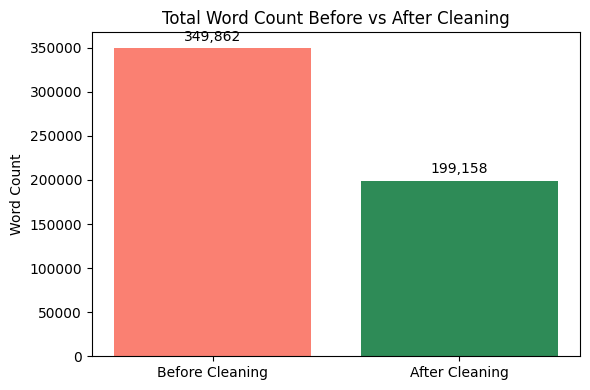

In [35]:
plt.figure(figsize=(6,4))
bars = plt.bar(['Before Cleaning', 'After Cleaning'], [total_words_before, total_words_after], color=['salmon', 'seagreen'])
plt.title('Total Word Count Before vs After Cleaning')
plt.ylabel('Word Count')

for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height):,}',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords='offset points',
                 ha='center', va='bottom')

plt.tight_layout()
plt.show()


This code generates a bar chart that visually compares the total word count in the dataset before and after text cleaning. It uses Matplotlib to plot two bars labeled "Before Cleaning" and "After Cleaning," colored differently for clarity. The chart helps illustrate the reduction in word count due to the removal of noise and irrelevant tokens during preprocessing.

In [36]:
df[['raw_tweet', 'tweet', 'tokenized', 'lemmatized', 'class']].to_csv('Exer2_YORO.csv', index=False)
df.to_csv('Exer2_YORO_full.csv', index=False)

This code saves the processed data into two CSV files. The first file, `Exer2_YORO.csv`, contains only the important columns: the original tweet, the tokenized version, the lemmatized version, and the class label. It’s meant to be a clean version for reporting or analysis. The second file, `Exer2_YORO_full.csv`, saves the entire DataFrame, including all intermediate steps like normalization and tagging, for backup or future reference.

---
#**PRE-PREPROCESSING AND POST-PREPROCESSING COMPARISON**
---

In [37]:
raw_df = pd.read_csv('labeled_data.csv')

processed_df = pd.read_csv('Exer2_YORO.csv')

comparison_df = pd.DataFrame({
    'Raw Tweet': raw_df['tweet'].head(10),
    'Cleaned Tokens': processed_df['tokenized'].head(10),
    'Lemmatized Tokens': processed_df['lemmatized'].head(10),
    'Label': processed_df['class'].head(10)
})

pd.set_option('display.max_colwidth', None)

comparison_df

,Raw Tweet,Cleaned Tokens,Lemmatized Tokens,Label
0,!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...,"['mayasolovely', 'woman', 'complain', 'cleaning', 'house', 'man', 'always', 'take', 'trash']","['mayasolovely', 'woman', 'complain', 'clean', 'house', 'man', 'always', 'take', 'trash']",2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!,"['mleew', 'boy', 'dats', 'coldtyga', 'dwn', 'bad', 'cuffin', 'dat', 'hoe', 'st', 'place']","['mleew', 'boy', 'that', 'coldtyga', 'down', 'bad', 'cuffin', 'that', 'hoe', 'st', 'place']",1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit,"['urkindofbrand', 'dawg', 'sbabylife', 'ever', 'fuck', 'bitch', 'start', 'cry', 'confused', 'shit']","['urkindofbrand', 'dawg', 'sbabylife', 'ever', 'fuck', 'bitch', 'start', 'cry', 'confuse', 'shit']",1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she look like a tranny,"['cganderson', 'vivabased', 'look', 'like', 'tranny']","['cganderson', 'vivabased', 'look', 'like', 'tranny']",1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you hear about me might be true or it might be faker than the bitch who told it to ya &#57361;,"['shenikaroberts', 'shit', 'hear', 'might', 'true', 'might', 'faker', 'bitch', 'told', 'ya']","['shenikaroberts', 'shit', 'hear', 'might', 'true', 'might', 'faker', 'bitch', 'told', 'you']",1
5,"!!!!!!!!!!!!!!!!!!""@T_Madison_x: The shit just blows me..claim you so faithful and down for somebody but still fucking with hoes! &#128514;&#128514;&#128514;""","['tmadisonx', 'shit', 'blows', 'meclaim', 'faithful', 'somebody', 'still', 'fucking', 'hoes']","['tmadisonx', 'shit', 'blow', 'meclaim', 'faithful', 'somebody', 'still', 'fuck', 'hoe']",1
6,"!!!!!!""@__BrighterDays: I can not just sit up and HATE on another bitch .. I got too much shit going on!""","['brighterdays', 'sit', 'hate', 'another', 'bitch', 'got', 'much', 'shit', 'going']","['brighterdays', 'sit', 'hate', 'another', 'bitch', 'get', 'much', 'shit', 'go']",1
7,!!!!&#8220;@selfiequeenbri: cause I'm tired of you big bitches coming for us skinny girls!!&#8221;,"['selfiequeenbri', 'tired', 'big', 'bitches', 'coming', 'us', 'skinny', 'girls']","['selfiequeenbri', 'tire', 'big', 'bitch', 'come', 'us', 'skinny', 'girl']",1
8,""" &amp; you might not get ya bitch back &amp; thats that ""","['might', 'get', 'ya', 'bitch', 'back']","['might', 'get', 'you', 'bitch', 'back']",1
9,""" @rhythmixx_ :hobbies include: fighting Mariam""\n\nbitch","['rhythmixx', 'hobbies', 'include', 'fighting', 'mariam', 'bitch']","['rhythmixx', 'hobby', 'include', 'fight', 'mariam', 'bitch']",1


Before preprocessing, the dataset contained raw tweets with noisy elements such as user mentions, hashtags, links, special characters, contractions, and informal words. These raw tweets were often difficult to analyze due to inconsistencies in spelling and grammar. After preprocessing, the data became cleaner and more structured. Tokenization broke down the tweets into individual words, normalization corrected informal or slang terms, and lemmatization reduced words to their base forms. This transformation made the data more suitable for analysis and improved the reliability of further NLP tasks such as classification or sentiment analysis.